# Guided Numeric Exploration — Everest Summit & the Death Zone
_Exploratory walkthrough of who summits, who turns around, and what queues appear above 8,000 m_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sergionefedov/everest-and-the-death-zone-will-they-summit](https://www.kaggle.com/datasets/sergionefedov/everest-and-the-death-zone-will-they-summit)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop. Functions are used to keep the exploratory process simple and reusable.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distribution](#Univariate)** <br>
	- 3.1 Outcomes: summit and serious incident
	- 3.2 Season, route, oxygen, operator
**4. [Summit Rate Over Time](#Time)** <br>
**5. [Experience, Weather, and Queue](#Drivers)** <br>
**6. [Turnaround Reasons](#Turnaround)** <br>
**7. [Operator, Sherpa Ratio, Hired Staff](#Team)** <br>
**8. [Leakage-Aware Multivariate Association](#Association)** <br>
**9. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This notebook is a guided observational walkthrough of an Everest expedition table: **45,000 climber-season rows** with demographics, prior high-altitude experience, team structure, oxygen use, weather scores, death-zone queueing, turnaround reasons, and two outcomes — `summited` (~38%) and `serious_incident` (~2%).

My goal is to understand **what associates with reaching the summit** — especially oxygen, prior 8,000 m peaks (flagged in the data dictionary as a strong predictor), weather, and post-2012 queueing — while refusing a quiet leakage trap: `turnaround_reason` includes the value `"summited"`, so using it to predict `summited` is nearly tautological.

I start with shapes and rates, then escalate to time trends, experience/weather/queue views, turnaround composition among non-summiters, team-structure crosstabs, and a leakage-free importance board. Interpretations are working notes about this table, not expedition advice.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "everest_summit_master.csv"
KAGGLE_SLUG = "sergionefedov/everest-and-the-death-zone-will-they-summit"

EXPECTED_COLS = [
    "climber_id", "year", "season", "route", "age", "sex", "is_hired_staff",
    "years_climbing", "prior_8000m_peaks", "prior_everest_attempts",
    "highest_prev_altitude_m", "operator_tier", "team_size", "sherpa_ratio",
    "uses_oxygen", "o2_start_altitude_m", "days_acclimatizing", "camps_established",
    "summit_window_days", "weather_score", "jetstream_risk",
    "queue_minutes_above_8000", "turnaround_reason", "serious_incident", "summited",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "everest" in p.name.lower() and "dictionary" not in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
assert len(df) == 45000, f"expected 45000 rows, got {len(df)}"
assert df["summited"].isin([0, 1]).all()
assert df["serious_incident"].isin([0, 1]).all()
assert df.isna().sum().sum() == 0, "expected zero missing values in master table"

# Leakage-aware flags
df["turnaround_is_summit_label"] = (df["turnaround_reason"] == "summited").astype(int)
df["post_2012"] = (df["year"] >= 2012).astype(int)

unique_count = []
for x in df.columns:
    unique_count.append([x, df[x].nunique(dropna=False), int(df[x].isnull().sum())])

print("Missing Values: {}".format(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Summit rate: {:.1%}".format(df["summited"].mean()))
print("Serious incident rate: {:.1%}".format(df["serious_incident"].mean()))
print("Identity check turnaround==summited vs summited: {:.1%}".format(
    (df["turnaround_is_summit_label"] == df["summited"]).mean()
))
print("Year range: {}–{}".format(df["year"].min(), df["year"].max()))


Missing Values: 0
Dataframe Dimension: 45000 Rows, 27 Columns
Summit rate: 38.0%
Serious incident rate: 2.2%
Identity check turnaround==summited vs summited: 100.0%
Year range: 1990–2026


**Code Explanation and Reasoning:** <br>
After resolving the CSV, I assert the full expected schema, exact row count, binary outcomes, and zero missingness. The identity printout is intentional: if `turnaround_reason == "summited"` tracks `summited` almost perfectly, then any model that includes `turnaround_reason` is doing boolean algebra, not mountaineering insight.

I also create `post_2012` early — death-zone queueing in this table jumps sharply around that era, and I want that cut available for every later plot.


In [3]:
df.sample(3, random_state=7)


,climber_id,year,season,route,age,sex,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,...,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,turnaround_reason,serious_incident,summited,turnaround_is_summit_label,post_2012
26019,CLB026019,2025,spring,North Ridge-NE,43,M,1,7,2,0,...,4,2,7.4,2.9,22,illness,0,0,0,1
5559,CLB005559,2006,autumn,North Ridge-NE,16,F,0,16,0,0,...,3,3,7.1,2.7,3,exhaustion_altitude_sickness,0,0,0,0
10834,CLB010834,2016,spring,South Col-SE Ridge,36,M,0,19,0,1,...,4,4,5.7,4.4,44,team_decision,0,0,0,1


In [4]:
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Missing"]).sort_values("Unique", ascending=False).head(20))

# Optional dictionary peek
dict_path = csv_path.parent / "data_dictionary.csv"
if dict_path.exists():
    dictionary = pd.read_csv(dict_path)
    print("\nData dictionary (first rows):")
    display(dictionary.head(10))


Dataframe Dimension: 45000 Rows, 27 Columns


,Column,Unique,Missing
0,climber_id,45000,0
10,highest_prev_altitude_m,4062,0
21,queue_minutes_above_8000,336,0
13,sherpa_ratio,288,0
20,jetstream_risk,101,0
19,weather_score,101,0
4,age,61,0
16,days_acclimatizing,49,0
1,year,37,0
7,years_climbing,36,0



Data dictionary (first rows):


,column,type,description
0,climber_id,string,Unique climber-attempt id
1,year,int,Year of the attempt (1990-2026)
2,season,string,spring / autumn / winter / summer (~86% spring)
3,route,string,South Col-SE Ridge (Nepal) / North Ridge-NE (T...
4,age,int,Climber age
5,sex,string,M / F
6,is_hired_staff,int,1 if hired high-altitude worker (e.g. Sherpa s...
7,years_climbing,int,Years of climbing experience
8,prior_8000m_peaks,int,Number of 8000m peaks previously summited — th...
9,prior_everest_attempts,int,Previous Everest attempts


**Interpretation** <br>
The table is unusually complete for expedition data (~38% summit, ~2% serious incident). The turnaround field encodes success as a category — useful for descriptive "why did people stop?" among failures, lethal as a predictor of success. Seasons, routes, and operator tiers look low-cardinality; continuous experience and weather fields will carry most of the multivariate story.


# **3. Univariate Distribution:** <a id="Univariate"></a>
### 3.1 Outcomes: summit and serious incident


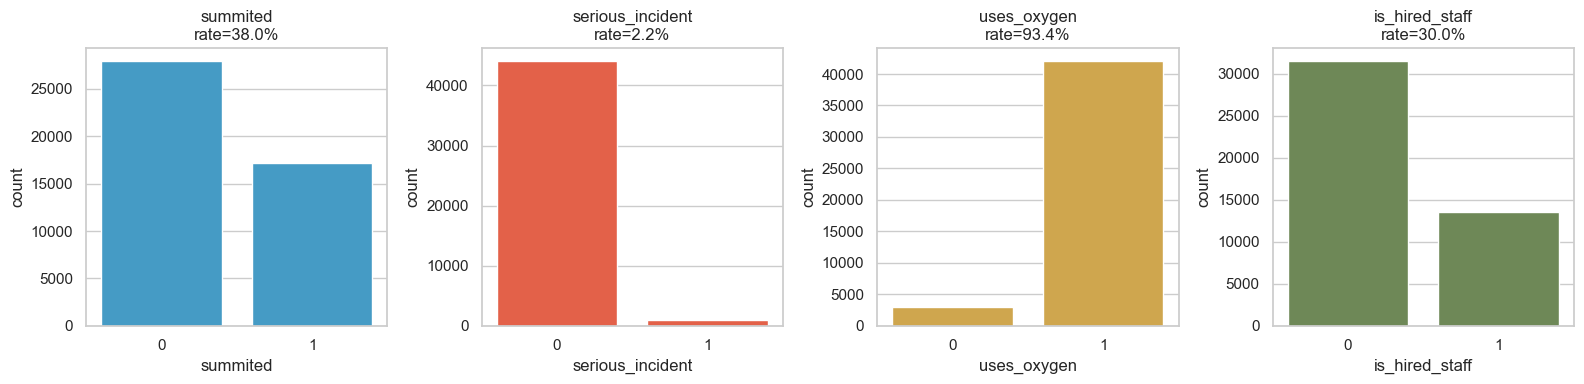

AGENT_SUMMARY outcomes: summit=0.380 serious=0.022 oxygen=0.934 hired_staff=0.300


In [5]:
f, ax = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for i, col in enumerate(["summited", "serious_incident", "uses_oxygen", "is_hired_staff"]):
    sns.countplot(x=df[col], ax=ax[i], color=["#30a2da", "#fc4f30", "#e5ae38", "#6d904f"][i])
    rate = df[col].mean()
    ax[i].set_title(f"{col}\nrate={rate:.1%}")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY outcomes: summit={:.3f} serious={:.3f} oxygen={:.3f} hired_staff={:.3f}".format(
    df["summited"].mean(), df["serious_incident"].mean(),
    df["uses_oxygen"].mean(), df["is_hired_staff"].mean(),
))


**Code Explanation:** <br>
Four countplots put the binary outcomes and two structural flags side by side. Empiric rates ride in the titles so the plot and the printed summary stay synchronized.


### 3.2 Season, route, oxygen, operator


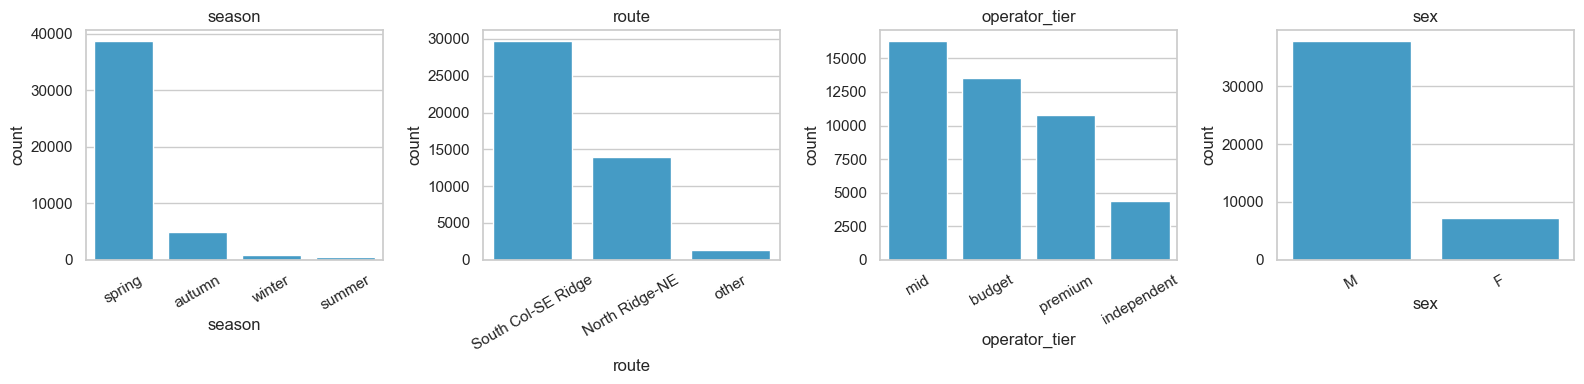

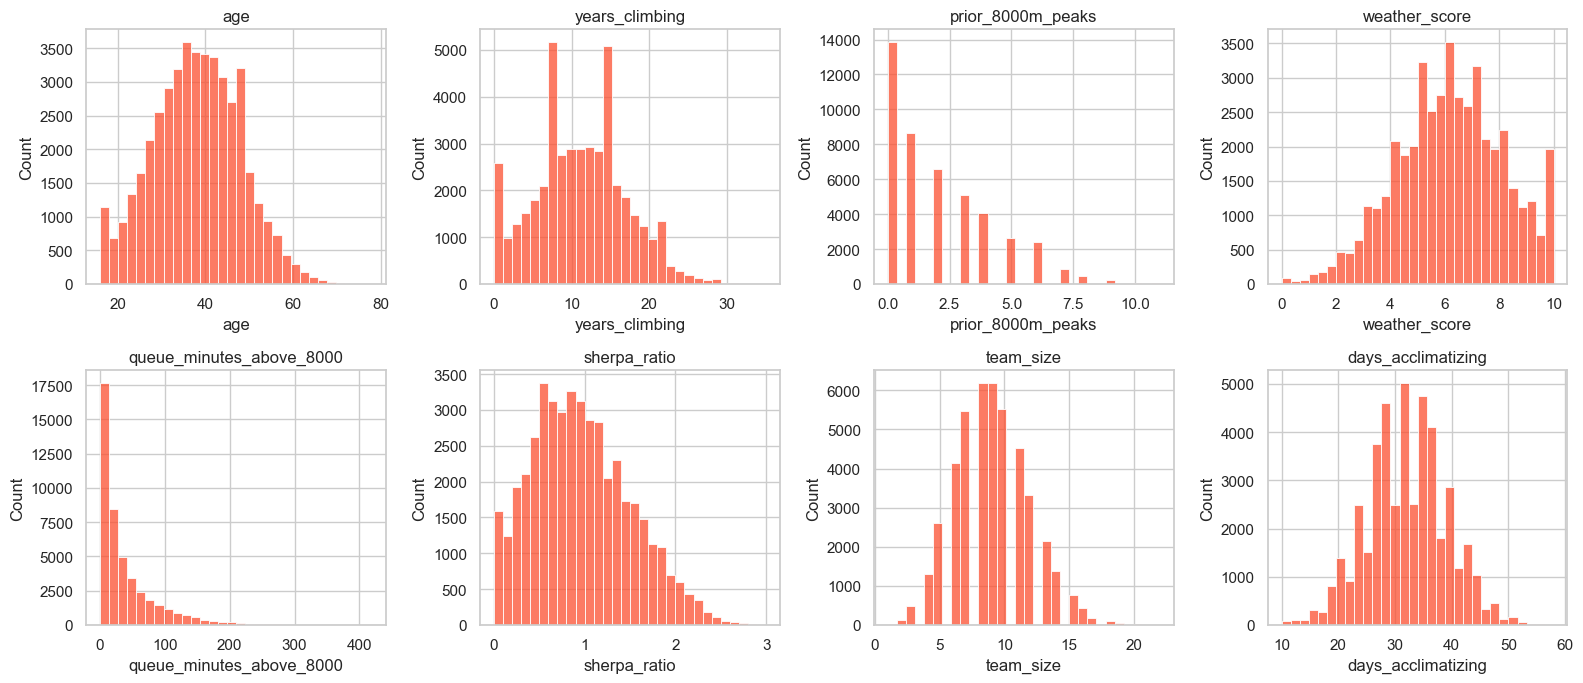

AGENT_SUMMARY season_counts:
 season
spring    38694
autumn     4999
winter      864
summer      443
AGENT_SUMMARY route_counts:
 route
South Col-SE Ridge    29670
North Ridge-NE        13993
other                  1337
AGENT_SUMMARY prior_8000m_peaks describe:
 count    45000.00
mean         2.09
std          2.15
min          0.00
25%          0.00
50%          1.00
75%          3.00
max         11.00


In [6]:
row_plots = ["season", "route", "operator_tier", "sex"]
f, axes = plt.subplots(1, len(row_plots), figsize=(16, 4))
for ax, col in zip(axes, row_plots):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color="#30a2da")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

cont = ["age", "years_climbing", "prior_8000m_peaks", "weather_score",
        "queue_minutes_above_8000", "sherpa_ratio", "team_size", "days_acclimatizing"]
f, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), cont):
    sns.histplot(df[col], bins=30, ax=ax, color="#fc4f30")
    ax.set_title(col)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY season_counts:\n", df["season"].value_counts().to_string())
print("AGENT_SUMMARY route_counts:\n", df["route"].value_counts().to_string())
print("AGENT_SUMMARY prior_8000m_peaks describe:\n", df["prior_8000m_peaks"].describe().round(2).to_string())


**Interpretation:** <br>
Spring dominates the calendar; a few route labels carry most of the volume. Prior 8,000 m peaks are right-skewed — many climbers have zero, a thinner tail has several. Queue minutes look bimodal across eras (we will confirm that next). Weather and sherpa ratio are continuous knobs worth conditioning on summit rate.


# **4. Summit Rate Over Time:** <a id="Time"></a>


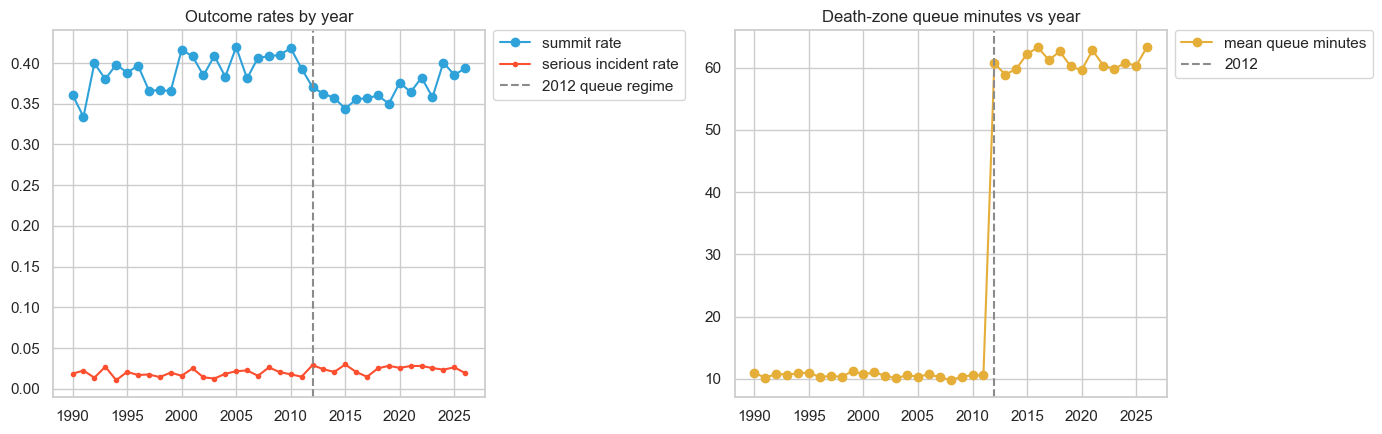

AGENT_SUMMARY queue_pre_2012_mean=10.5 queue_post_2012_mean=61.1
AGENT_SUMMARY summit_rate_1990s=37.6% summit_rate_2020s=38.0%


In [7]:
yearly = df.groupby("year").agg(
    n=("summited", "size"),
    summit_rate=("summited", "mean"),
    serious_rate=("serious_incident", "mean"),
    mean_queue=("queue_minutes_above_8000", "mean"),
    oxygen_rate=("uses_oxygen", "mean"),
).reset_index()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(yearly["year"], yearly["summit_rate"], color="#30a2da", marker="o", label="summit rate")
ax[0].plot(yearly["year"], yearly["serious_rate"], color="#fc4f30", marker=".", label="serious incident rate")
ax[0].axvline(2012, color="#8b8b8b", ls="--", label="2012 queue regime")
ax[0].set_title("Outcome rates by year")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

ax[1].plot(yearly["year"], yearly["mean_queue"], color="#e5ae38", marker="o", label="mean queue minutes")
ax[1].axvline(2012, color="#8b8b8b", ls="--", label="2012")
ax[1].set_title("Death-zone queue minutes vs year")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY queue_pre_2012_mean={:.1f} queue_post_2012_mean={:.1f}".format(
    df.loc[df["year"] < 2012, "queue_minutes_above_8000"].mean(),
    df.loc[df["year"] >= 2012, "queue_minutes_above_8000"].mean(),
))
print("AGENT_SUMMARY summit_rate_1990s={:.1%} summit_rate_2020s={:.1%}".format(
    df.loc[df["year"] < 2000, "summited"].mean(),
    df.loc[df["year"] >= 2020, "summited"].mean(),
))


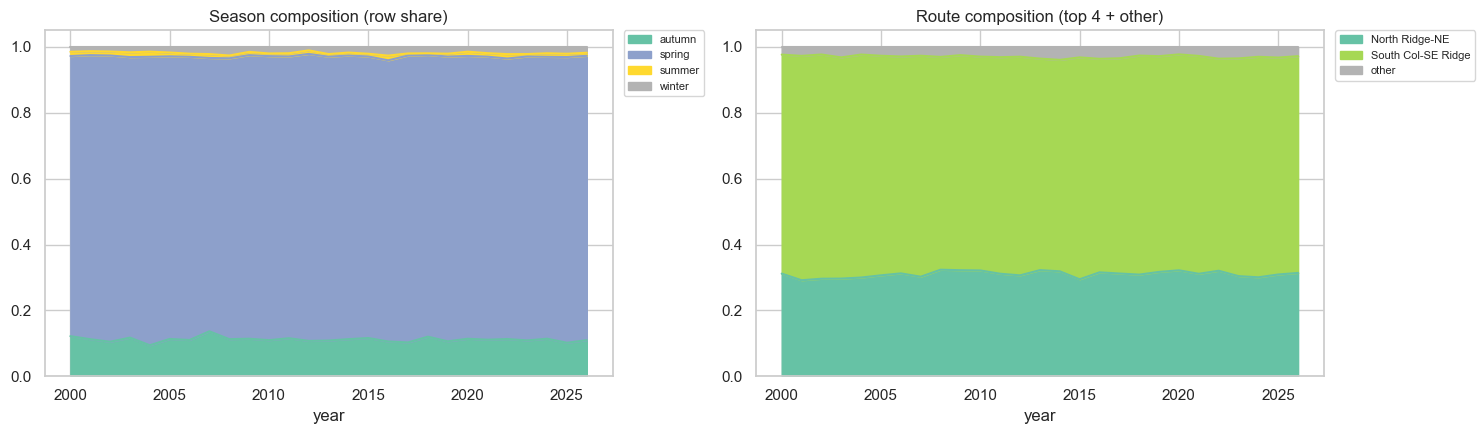

AGENT_SUMMARY season_summit_rate:
 season
summer    0.406
spring    0.386
autumn    0.348
winter    0.318
AGENT_SUMMARY route_summit_rate:
 route
other                 0.388
South Col-SE Ridge    0.384
North Ridge-NE        0.371


In [8]:
# Season / route composition over time (stacked shares for recent decades)
era = df[df["year"] >= 2000].copy()
season_year = pd.crosstab(era["year"], era["season"], normalize="index")
route_year = pd.crosstab(era["year"], era["route"], normalize="index")

f, ax = plt.subplots(1, 2, figsize=(15, 4.5))
season_year.plot(kind="area", stacked=True, ax=ax[0], colormap="Set2")
ax[0].set_title("Season composition (row share)")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)

# Top routes only for readability
top_routes = df["route"].value_counts().head(4).index
route_focus = era.copy()
route_focus["route_plot"] = np.where(route_focus["route"].isin(top_routes), route_focus["route"], "other")
route_year2 = pd.crosstab(route_focus["year"], route_focus["route_plot"], normalize="index")
route_year2.plot(kind="area", stacked=True, ax=ax[1], colormap="Set2")
ax[1].set_title("Route composition (top 4 + other)")
ax[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY season_summit_rate:\n", df.groupby("season")["summited"].mean().sort_values(ascending=False).round(3).to_string())
print("AGENT_SUMMARY route_summit_rate:\n", df.groupby("route")["summited"].mean().sort_values(ascending=False).round(3).to_string())


**How to Interpret:** <br>
The queue series is the cleanest structural break in the table: mean death-zone minutes jump from ~10 before 2012 to ~60 after. Summit rates move more slowly and mix technology (oxygen norms), crowding, and who shows up. Season/route stacked areas show whether the *mix* of attempts is shifting under the outcome trend.


# **5. Experience, Weather, and Queue:** <a id="Drivers"></a>


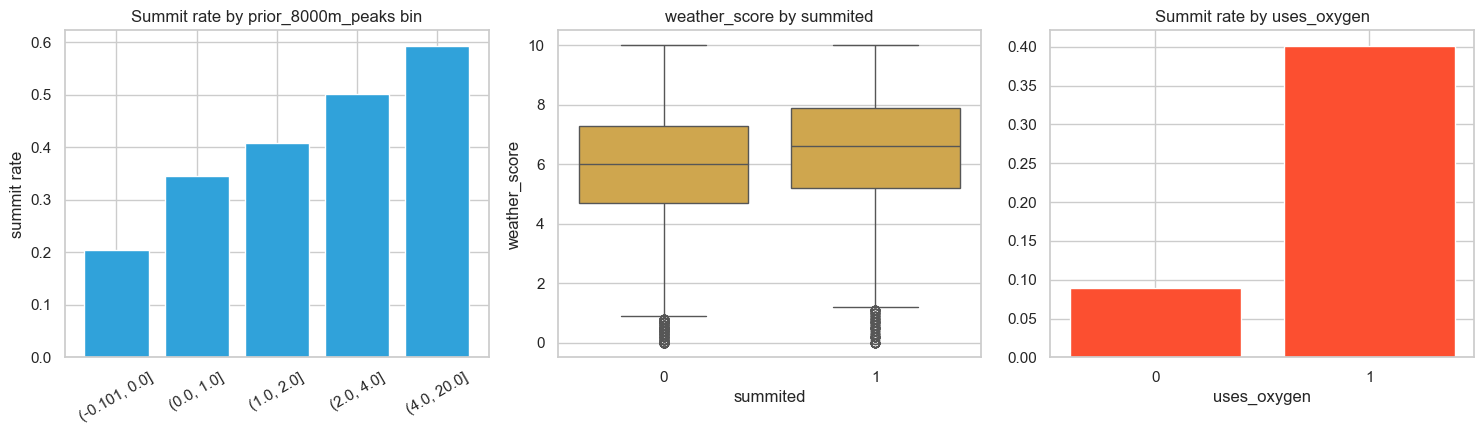

AGENT_SUMMARY summit_by_prior_bin:
                 mean  count
prior_bin                  
(-0.101, 0.0]  0.206  13887
(0.0, 1.0]     0.345   8632
(1.0, 2.0]     0.408   6583
(2.0, 4.0]     0.503   9169
(4.0, 20.0]    0.593   6729
AGENT_SUMMARY summit_by_oxygen:
               mean  count
uses_oxygen              
0            0.089   2976
1            0.401  42024
AGENT_SUMMARY weather_mean_summit0=5.97 summit1=6.53


In [9]:
# prior_8000m_peaks, weather_score, oxygen vs summit
f, axes = plt.subplots(1, 3, figsize=(15, 4.5))

tmp = df.copy()
tmp["prior_bin"] = pd.cut(tmp["prior_8000m_peaks"], bins=[-0.1, 0, 1, 2, 4, 20], include_lowest=True)
prior_rate = tmp.groupby("prior_bin", observed=True)["summited"].agg(["mean", "count"])
axes[0].bar(prior_rate.index.astype(str), prior_rate["mean"], color="#30a2da")
axes[0].set_title("Summit rate by prior_8000m_peaks bin")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("summit rate")

sns.boxplot(data=df, x="summited", y="weather_score", ax=axes[1], color="#e5ae38")
axes[1].set_title("weather_score by summited")

oxy = df.groupby("uses_oxygen")["summited"].mean()
axes[2].bar(oxy.index.astype(str), oxy.values, color="#fc4f30")
axes[2].set_title("Summit rate by uses_oxygen")
axes[2].set_xlabel("uses_oxygen")
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY summit_by_prior_bin:\n", prior_rate.round(3).to_string())
print("AGENT_SUMMARY summit_by_oxygen:\n", df.groupby("uses_oxygen")["summited"].agg(["mean", "count"]).round(3).to_string())
print("AGENT_SUMMARY weather_mean_summit0={:.2f} summit1={:.2f}".format(
    df.loc[df["summited"] == 0, "weather_score"].mean(),
    df.loc[df["summited"] == 1, "weather_score"].mean(),
))


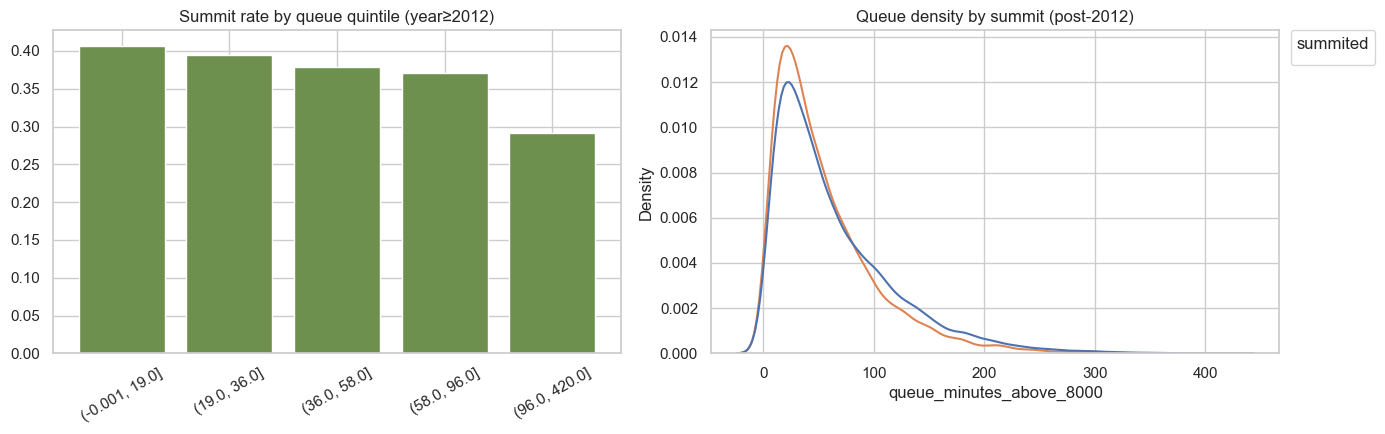

AGENT_SUMMARY queue_quintile_summit:
                  mean  count
queue_q                     
(-0.001, 19.0]  0.407   4975
(19.0, 36.0]    0.395   5175
(36.0, 58.0]    0.379   4881
(58.0, 96.0]    0.371   4892
(96.0, 420.0]   0.292   4921


In [10]:
# Queue vs summit within post-2012 regime (pre-2012 queues are a different world)
post = df[df["year"] >= 2012].copy()
post["queue_q"] = pd.qcut(post["queue_minutes_above_8000"], 5, duplicates="drop")
qrate = post.groupby("queue_q", observed=True)["summited"].agg(["mean", "count"])

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(qrate.index.astype(str), qrate["mean"], color="#6d904f")
ax[0].set_title("Summit rate by queue quintile (year≥2012)")
ax[0].tick_params(axis="x", rotation=30)

sns.kdeplot(data=post, x="queue_minutes_above_8000", hue="summited", common_norm=False, ax=ax[1])
ax[1].set_title("Queue density by summit (post-2012)")
ax[1].legend(title="summited", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY queue_quintile_summit:\n", qrate.round(3).to_string())


**Interpretation:** <br>
Prior 8,000 m peaks line up with summit rate in the direction the dictionary advertises — more prior peaks, higher success in this table. Oxygen use is a strong compositional split. Weather scores sit higher among summiters on average. Queue effects inside the crowded post-2012 regime are subtler than the era break itself: crowding changes the environment, then within that environment the gradient can be flatter.


# **6. Turnaround Reasons:** <a id="Turnaround"></a>


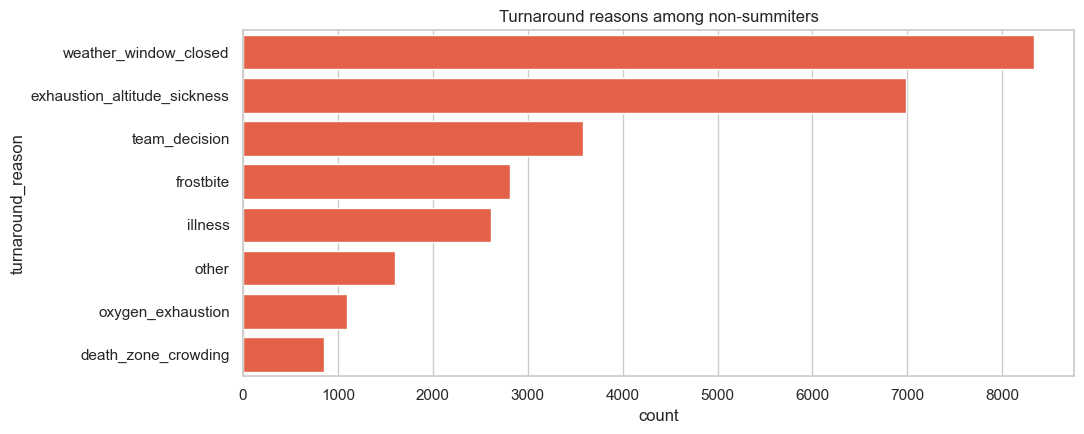

AGENT_SUMMARY turnaround_non_summit:
 turnaround_reason
weather_window_closed           8338
exhaustion_altitude_sickness    6988
team_decision                   3585
frostbite                       2809
illness                         2612
other                           1600
oxygen_exhaustion               1099
death_zone_crowding              850
AGENT_SUMMARY turnaround_share_by_era:
 turnaround_reason  death_zone_crowding  exhaustion_altitude_sickness  frostbite  illness  other  oxygen_exhaustion  team_decision  weather_window_closed
post_2012                                                                                                                                               
2012+                            0.054                         0.241      0.099    0.092  0.056              0.038          0.126                  0.294
pre-2012                         0.000                         0.263      0.103    0.096  0.060              0.041          0.132                  0.

In [11]:
# Among non-summiters only — never use turnaround_reason to predict summited
non = df[df["summited"] == 0].copy()
assert (non["turnaround_reason"] != "summited").all(), "non-summiters should not carry summited reason"

reasons = non["turnaround_reason"].value_counts()
f, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=reasons.values, y=reasons.index, ax=ax, color="#fc4f30")
ax.set_title("Turnaround reasons among non-summiters")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

# Reason mix by era
era_reason = pd.crosstab(non["post_2012"].map({0: "pre-2012", 1: "2012+"}), non["turnaround_reason"], normalize="index")
print("AGENT_SUMMARY turnaround_non_summit:\n", reasons.to_string())
print("AGENT_SUMMARY turnaround_share_by_era:\n", era_reason.round(3).to_string())


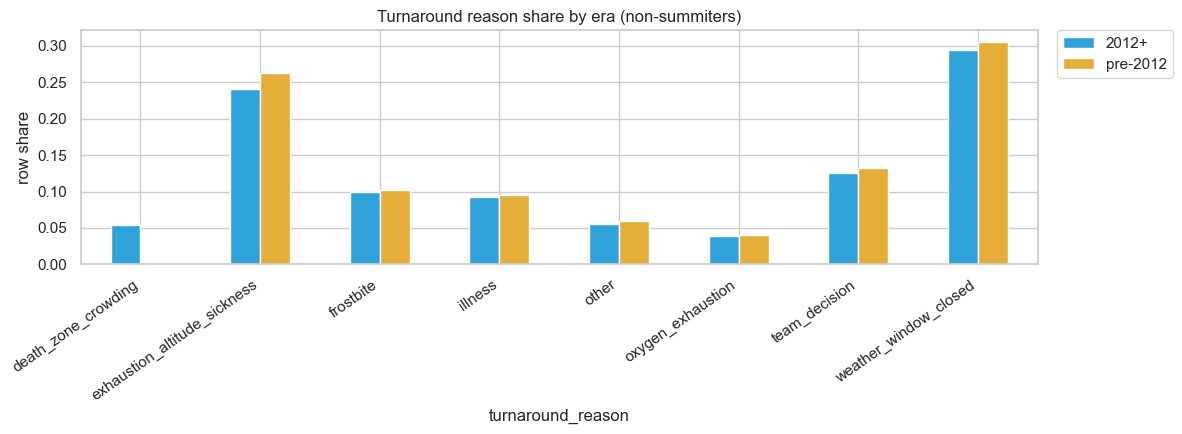

In [12]:
f, ax = plt.subplots(figsize=(12, 4.5))
era_reason.T.plot(kind="bar", ax=ax, color=["#30a2da", "#e5ae38"])
ax.set_title("Turnaround reason share by era (non-summiters)")
ax.set_ylabel("row share")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


**Code Explanation:** <br>
I filter to `summited == 0` before counting reasons, and assert that `"summited"` never appears in that subset. That keeps the descriptive story honest: these are *failure modes*, not a second encoding of the label. Comparing pre/post-2012 shares asks whether crowding (and related categories like death-zone crowding) grew as a stated reason.


# **7. Operator, Sherpa Ratio, Hired Staff:** <a id="Team"></a>


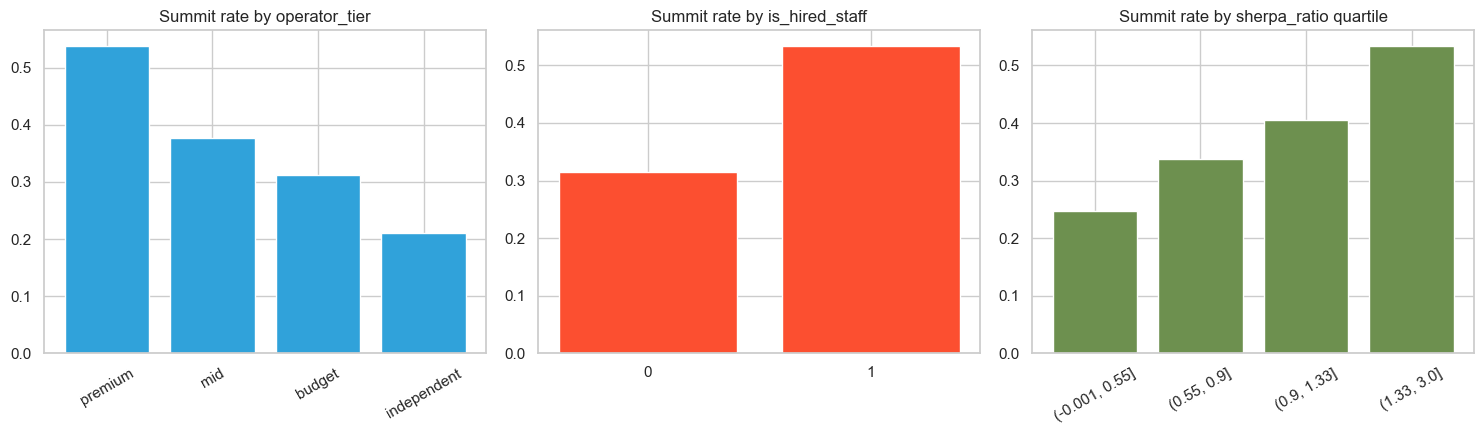

AGENT_SUMMARY operator_tier:
                 mean  count
operator_tier              
premium        0.538  10816
mid            0.377  16267
budget         0.313  13532
independent    0.211   4385
AGENT_SUMMARY hired_staff_summit:
                  mean  count
is_hired_staff              
0               0.315  31492
1               0.534  13508
AGENT_SUMMARY sherpa_quartile_summit:
                  mean  count
sherpa_q                    
(-0.001, 0.55]  0.247  11296
(0.55, 0.9]     0.338  11253
(0.9, 1.33]     0.405  11382
(1.33, 3.0]     0.534  11069


In [13]:
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))

op = df.groupby("operator_tier")["summited"].agg(["mean", "count"]).sort_values("mean", ascending=False)
ax[0].bar(op.index.astype(str), op["mean"], color="#30a2da")
ax[0].set_title("Summit rate by operator_tier")
ax[0].tick_params(axis="x", rotation=30)

hired = df.groupby("is_hired_staff")["summited"].mean()
ax[1].bar(hired.index.astype(str), hired.values, color="#fc4f30")
ax[1].set_title("Summit rate by is_hired_staff")

df["sherpa_q"] = pd.qcut(df["sherpa_ratio"], 4, duplicates="drop")
sq = df.groupby("sherpa_q", observed=True)["summited"].mean()
ax[2].bar(sq.index.astype(str), sq.values, color="#6d904f")
ax[2].set_title("Summit rate by sherpa_ratio quartile")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY operator_tier:\n", op.round(3).to_string())
print("AGENT_SUMMARY hired_staff_summit:\n", df.groupby("is_hired_staff")["summited"].agg(["mean", "count"]).round(3).to_string())
print("AGENT_SUMMARY sherpa_quartile_summit:\n", df.groupby("sherpa_q", observed=True)["summited"].agg(["mean", "count"]).round(3).to_string())


**Interpretation:** <br>
Operator tier and sherpa ratio are team-structure proxies. Hired staff may summit at different rates for role reasons (job vs guided client), not because "staff are better climbers" in a moral sense. I treat these as compositional associations that belong beside experience and oxygen, not instead of them.


# **8. Leakage-Aware Multivariate Association:** <a id="Association"></a>


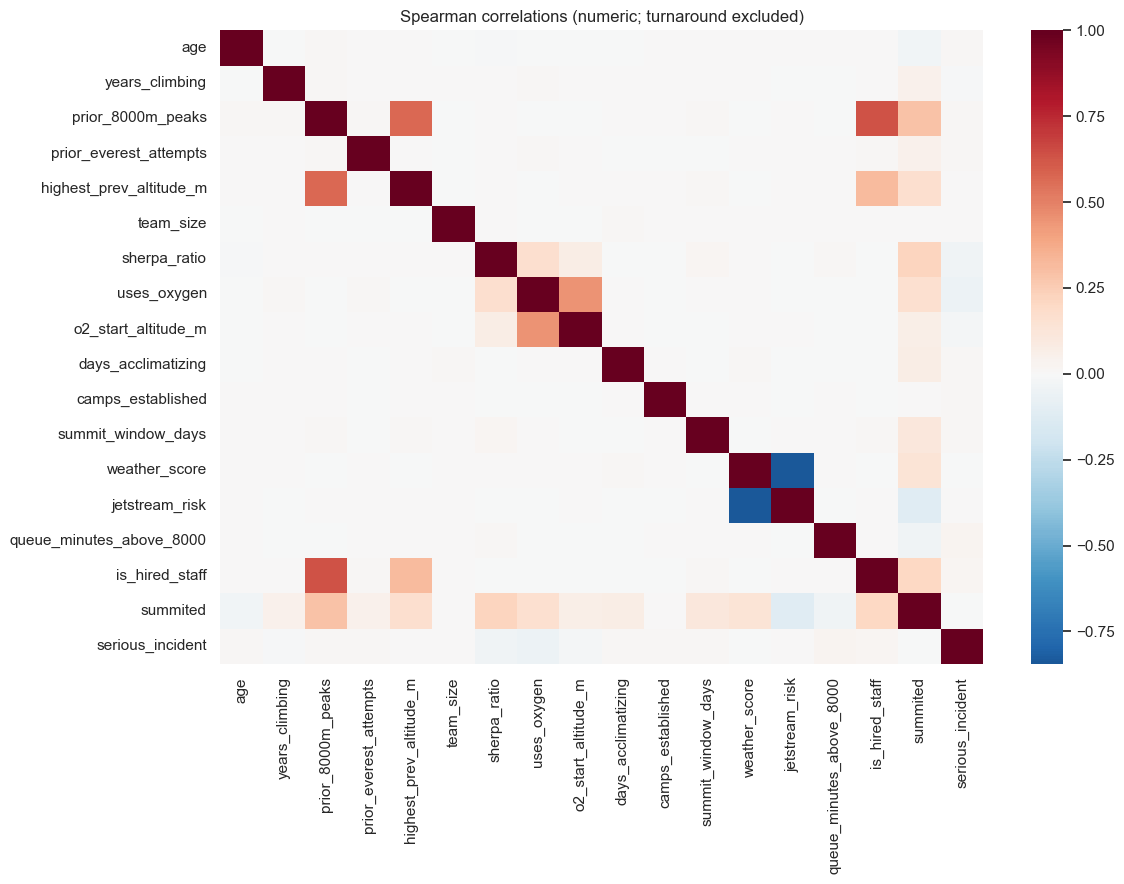

AGENT_SUMMARY corr_with_summited:
 prior_8000m_peaks           0.290
sherpa_ratio                0.225
is_hired_staff              0.207
highest_prev_altitude_m     0.170
uses_oxygen                 0.160
weather_score               0.139
jetstream_risk             -0.122
summit_window_days          0.107
days_acclimatizing          0.076
o2_start_altitude_m         0.068
prior_everest_attempts      0.053
years_climbing              0.050
queue_minutes_above_8000   -0.044
age                        -0.034
serious_incident           -0.003
camps_established           0.002
team_size                  -0.001


In [14]:
# Correlation heatmap — numeric features only (no turnaround_reason)
num_cols = [
    "age", "years_climbing", "prior_8000m_peaks", "prior_everest_attempts",
    "highest_prev_altitude_m", "team_size", "sherpa_ratio", "uses_oxygen",
    "o2_start_altitude_m", "days_acclimatizing", "camps_established",
    "summit_window_days", "weather_score", "jetstream_risk",
    "queue_minutes_above_8000", "is_hired_staff", "summited", "serious_incident",
]
corr = df[num_cols].corr(method="spearman")

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, square=False)
ax.set_title("Spearman correlations (numeric; turnaround excluded)")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY corr_with_summited:\n",
      corr["summited"].drop("summited").sort_values(key=np.abs, ascending=False).round(3).to_string())


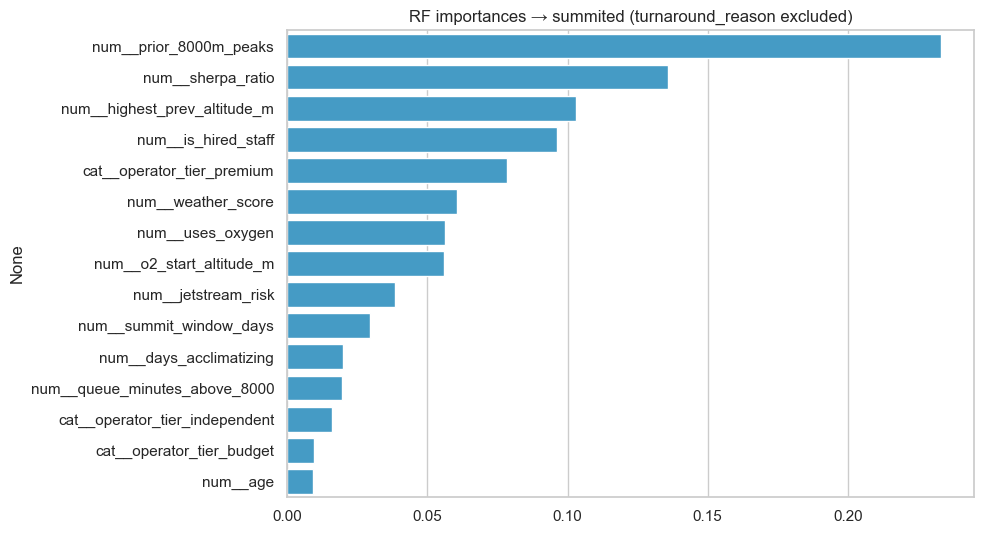

AGENT_SUMMARY rf_top15:
 num__prior_8000m_peaks            0.233
num__sherpa_ratio                 0.136
num__highest_prev_altitude_m      0.103
num__is_hired_staff               0.096
cat__operator_tier_premium        0.078
num__weather_score                0.060
num__uses_oxygen                  0.056
num__o2_start_altitude_m          0.056
num__jetstream_risk               0.038
num__summit_window_days           0.030
num__days_acclimatizing           0.020
num__queue_minutes_above_8000     0.020
cat__operator_tier_independent    0.016
cat__operator_tier_budget         0.010
num__age                          0.009
AGENT_SUMMARY train_acc=0.713 base_rate=0.380


In [15]:
# RandomForest importances — leakage-free feature set
feat_cat = ["season", "route", "sex", "operator_tier"]
feat_num = [
    "age", "years_climbing", "prior_8000m_peaks", "prior_everest_attempts",
    "highest_prev_altitude_m", "team_size", "sherpa_ratio", "uses_oxygen",
    "o2_start_altitude_m", "days_acclimatizing", "camps_established",
    "summit_window_days", "weather_score", "jetstream_risk",
    "queue_minutes_above_8000", "is_hired_staff", "year",
]
# Explicitly excluded: turnaround_reason (contains the label)
assert "turnaround_reason" not in feat_cat + feat_num

X = df[feat_cat + feat_num]
y = df["summited"]
pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), feat_cat),
        ("num", "passthrough", feat_num),
    ]
)
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(
        n_estimators=250, max_depth=8, min_samples_leaf=30,
        random_state=0, n_jobs=-1,
    )),
])
pipe.fit(X, y)
rf = pipe.named_steps["rf"]
feat_names = list(pipe.named_steps["pre"].get_feature_names_out())
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)

f, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("RF importances → summited (turnaround_reason excluded)")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY rf_top15:\n", imp.round(3).to_string())
print("AGENT_SUMMARY train_acc={:.3f} base_rate={:.3f}".format(pipe.score(X, y), y.mean()))


**How to Interpret:** <br>
Read the `summited` column of the heatmap first. Prior 8,000 m experience, oxygen, and weather typically rise near the top; queue and year can proxy the crowding regime. The RF board is fit on the full table for exploration — nonlinear confirmation, not a deployable risk score. The important methodological point is negative: **`turnaround_reason` is absent**. Including it would crown itself as the "best predictor" and teach nothing.


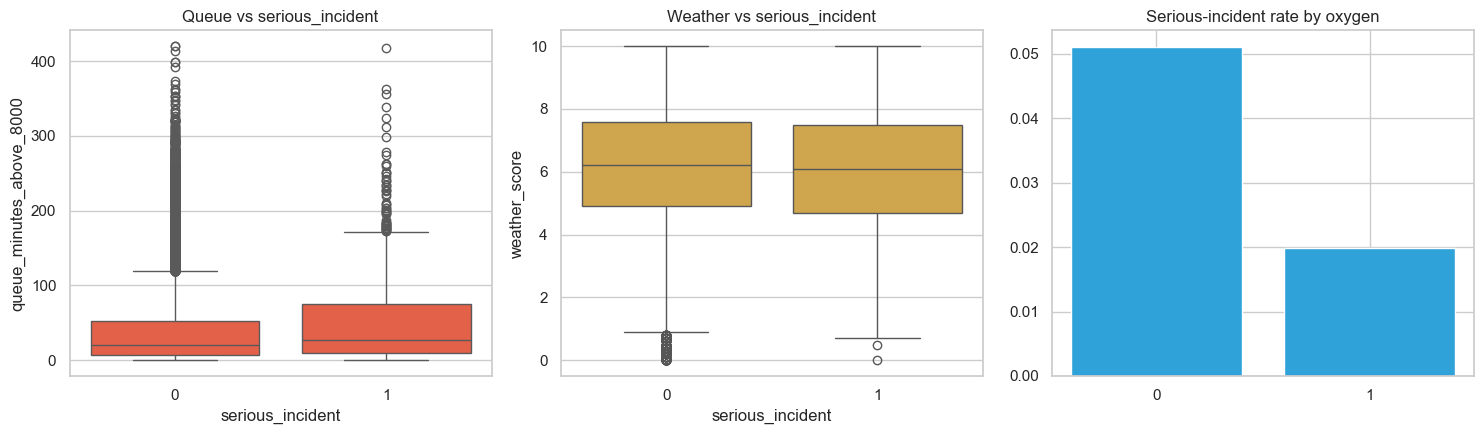

AGENT_SUMMARY serious_by_oxygen:
                mean  count
uses_oxygen               
0            0.0511   2976
1            0.0198  42024
AGENT_SUMMARY serious_rate_pre2012=1.856% post2012=2.459%


In [16]:
# Serious incident — rare outcome, conditioned carefully
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="serious_incident", y="queue_minutes_above_8000", ax=ax[0], color="#fc4f30")
ax[0].set_title("Queue vs serious_incident")

sns.boxplot(data=df, x="serious_incident", y="weather_score", ax=ax[1], color="#e5ae38")
ax[1].set_title("Weather vs serious_incident")

si_oxy = df.groupby("uses_oxygen")["serious_incident"].mean()
ax[2].bar(si_oxy.index.astype(str), si_oxy.values, color="#30a2da")
ax[2].set_title("Serious-incident rate by oxygen")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY serious_by_oxygen:\n", df.groupby("uses_oxygen")["serious_incident"].agg(["mean", "count"]).round(4).to_string())
print("AGENT_SUMMARY serious_rate_pre2012={:.3%} post2012={:.3%}".format(
    df.loc[df["year"] < 2012, "serious_incident"].mean(),
    df.loc[df["year"] >= 2012, "serious_incident"].mean(),
))


**Interpretation:** <br>
Serious incidents are rare, so rate differences need large denominators. I treat these plots as hypothesis generators: does the crowded post-2012 queue regime coincide with a higher incident rate, or is the signal mostly weather/oxygen selection? The printed rates keep me honest about magnitude.


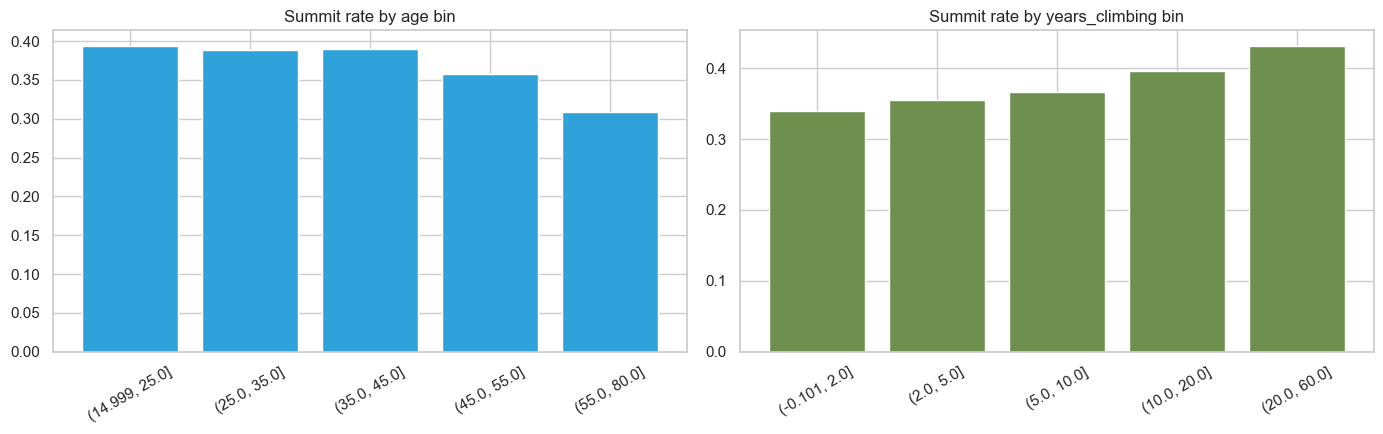

AGENT_SUMMARY age_summit:
                  mean  count
age_bin                     
(14.999, 25.0]  0.394   4868
(25.0, 35.0]    0.389  13441
(35.0, 45.0]    0.389  16529
(45.0, 55.0]    0.357   8303
(55.0, 80.0]    0.308   1859
AGENT_SUMMARY years_climbing_summit:
                  mean  count
years_climbing              
(-0.101, 2.0]   0.340   3567
(2.0, 5.0]      0.355   4576
(5.0, 10.0]     0.366  12916
(10.0, 20.0]    0.395  21378
(20.0, 60.0]    0.432   2563


In [17]:
# Age and years_climbing vs summit
df["age_bin"] = pd.cut(df["age"], bins=[15, 25, 35, 45, 55, 80], include_lowest=True)
age_rate = df.groupby("age_bin", observed=True)["summited"].agg(["mean", "count"])
climb_bin = pd.cut(df["years_climbing"], bins=[-0.1, 2, 5, 10, 20, 60], include_lowest=True)
climb_rate = df.groupby(climb_bin, observed=True)["summited"].agg(["mean", "count"])

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(age_rate.index.astype(str), age_rate["mean"], color="#30a2da")
ax[0].set_title("Summit rate by age bin")
ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(climb_rate.index.astype(str), climb_rate["mean"], color="#6d904f")
ax[1].set_title("Summit rate by years_climbing bin")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY age_summit:\n", age_rate.round(3).to_string())
print("AGENT_SUMMARY years_climbing_summit:\n", climb_rate.round(3).to_string())


**Code Explanation:** <br>
Age and career length are related but not identical — a young guide with many prior peaks differs from an older first-timer. Binning keeps the rate curves readable; counts in the printed table flag sparse edge bins.


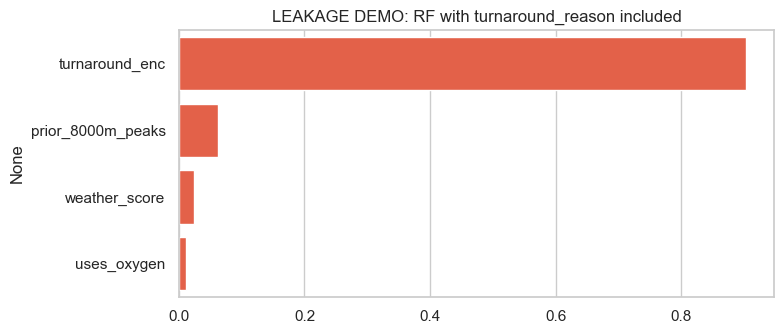

AGENT_SUMMARY leakage_importances:
 turnaround_enc       0.903
prior_8000m_peaks    0.062
weather_score        0.023
uses_oxygen          0.012
AGENT_SUMMARY leakage_train_acc=1.000 (near-tautology if turnaround dominates)


In [18]:
# Demonstrate leakage: naive model WITH turnaround_reason (for contrast only)
from sklearn.preprocessing import LabelEncoder
leak = df.copy()
leak["turnaround_enc"] = LabelEncoder().fit_transform(leak["turnaround_reason"])
X_leak = leak[["turnaround_enc", "prior_8000m_peaks", "weather_score", "uses_oxygen"]]
rf_leak = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=0)
rf_leak.fit(X_leak, leak["summited"])
imp_leak = pd.Series(rf_leak.feature_importances_, index=X_leak.columns).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=imp_leak.values, y=imp_leak.index, ax=ax, color="#fc4f30")
ax.set_title("LEAKAGE DEMO: RF with turnaround_reason included")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY leakage_importances:\n", imp_leak.round(3).to_string())
print("AGENT_SUMMARY leakage_train_acc={:.3f} (near-tautology if turnaround dominates)".format(rf_leak.score(X_leak, leak["summited"])))


**How to Interpret:** <br>
This plot is a cautionary mirror of the leakage-free board. If `turnaround_enc` hogs importance and accuracy approaches perfection, the lesson writes itself: the reason field knows the ending. Keep it out of predictors; keep it in descriptive failure analysis.


# **9. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A dense climber-attempt panel (1990–2026) with experience, team, oxygen, weather, death-zone queueing, turnaround narratives, summit, and rare serious incidents.

**What stands out:** <br>
1. **Summit is common but far from guaranteed** (~38%); serious incidents are rare (~2%) and need careful separate study.
2. **Prior 8,000 m peaks associate strongly with summit** — matching the dictionary's claim in direction.
3. **Oxygen and weather are first-class companions** to success in bivariate and multivariate views.
4. **Death-zone queueing is a post-2012 phenomenon** in this table: mean queue minutes jump roughly sixfold after 2012.
5. **Turnaround reasons are for failures.** The category `"summited"` is label leakage if used as a predictor.
6. **Team structure matters at the margin** — operator tier, sherpa ratio, and hired-staff status shift rates, with role confounding.

**Open follow-ups:** <br>
- Within post-2012 seasons, does queue length predict serious incidents more than summit failure?
- How much of the oxygen effect is selection (who chooses oxygen) versus physiology?
- Are operator-tier differences stable after matching on prior peaks and weather?
- What turnaround reasons rose fastest after the queue regime shift?
